<a href="https://colab.research.google.com/github/LoadBR/Gelt2012502-Processamento-Sinais-1/blob/main/Aula-01/Codigo/AP1_Sinais_e_Sistemas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/LoadBR/Gelt2012502-Processamento-Sinais-1.git


Cloning into 'Gelt2012502-Processamento-Sinais-1'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 39 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 138.74 KiB | 7.71 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [2]:
%cd /content/Gelt2012502-Processamento-Sinais-1

/content/Gelt2012502-Processamento-Sinais-1


In [3]:
!ls

Aula-01  README.md


In [4]:
!ls Aula-01

Codigo	Dados  README.md  Relatorio  Resultados


In [5]:
!ls Aula-01/Dados

handel.wav  h_banheiro.wav  sinal_taca.wav


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.io import wavfile
from scipy.signal import chirp, resample_poly, fftconvolve
from scipy.fft import fft, fftfreq

from IPython.display import Audio, display

In [7]:
PASTA_DADOS = Path("Aula-01/Dados")
PASTA_RESULTADOS = Path("Aula-01/Resultados")

print("Pasta de dados:", PASTA_DADOS)
print("Pasta de resultados:", PASTA_RESULTADOS)

Pasta de dados: Aula-01/Dados
Pasta de resultados: Aula-01/Resultados


In [8]:
fs = 44100
duracao = 0.5
f = 500

t = np.arange(0, duracao, 1/fs)
x = np.cos(2 * np.pi * f * t)

print("Frequência de amostragem:", fs, "Hz")
print("Duração:", duracao, "s")
print("Frequência do sinal:", f, "Hz")
print("Número de amostras:", len(x))

Frequência de amostragem: 44100 Hz
Duração: 0.5 s
Frequência do sinal: 500 Hz
Número de amostras: 22050


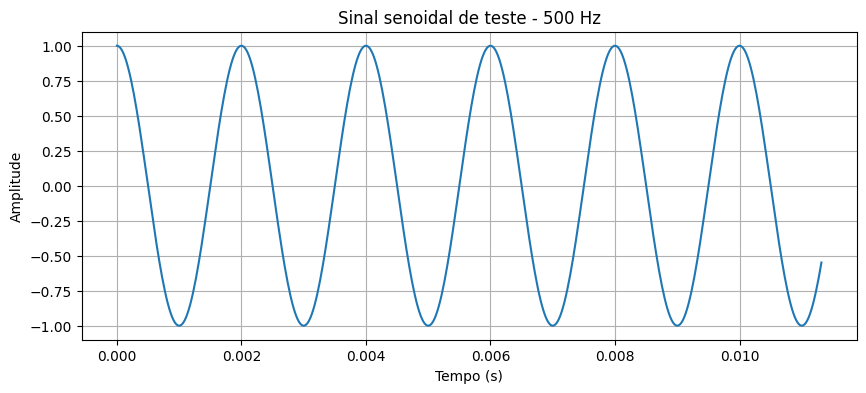

In [10]:
plt.figure(figsize=(10, 4))

plt.plot(t[:500], x[:500])

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sinal senoidal de teste - 500 Hz")
plt.grid()

plt.show()


In [11]:
display(Audio(x, rate=fs))


# Questão 1 — Sinais senoidais

Geração, visualização e reprodução de sinais senoidais de 500 Hz, 5 kHz e 10 kHz, com frequência de amostragem de 44,1 kHz e duração de 5 segundos.

In [12]:
# Parâmetros da Questão 1
fs = 44100              # Frequência de amostragem em Hz
duracao = 5             # Duração do sinal em segundos
frequencias = [500, 5000, 10000]

# Vetor de tempo
t = np.arange(0, duracao, 1/fs)

print("Frequência de amostragem:", fs, "Hz")
print("Duração:", duracao, "s")
print("Número de amostras:", len(t))
print("Frequências analisadas:", frequencias, "Hz")

Frequência de amostragem: 44100 Hz
Duração: 5 s
Número de amostras: 220500
Frequências analisadas: [500, 5000, 10000] Hz


In [13]:
# Geração dos sinais senoidais
sinais = {}

for f in frequencias:
    sinais[f] = np.cos(2 * np.pi * f * t)

print("Sinais gerados:")
for f in frequencias:
    print(f"{f} Hz -> {len(sinais[f])} amostras")

Sinais gerados:
500 Hz -> 220500 amostras
5000 Hz -> 220500 amostras
10000 Hz -> 220500 amostras


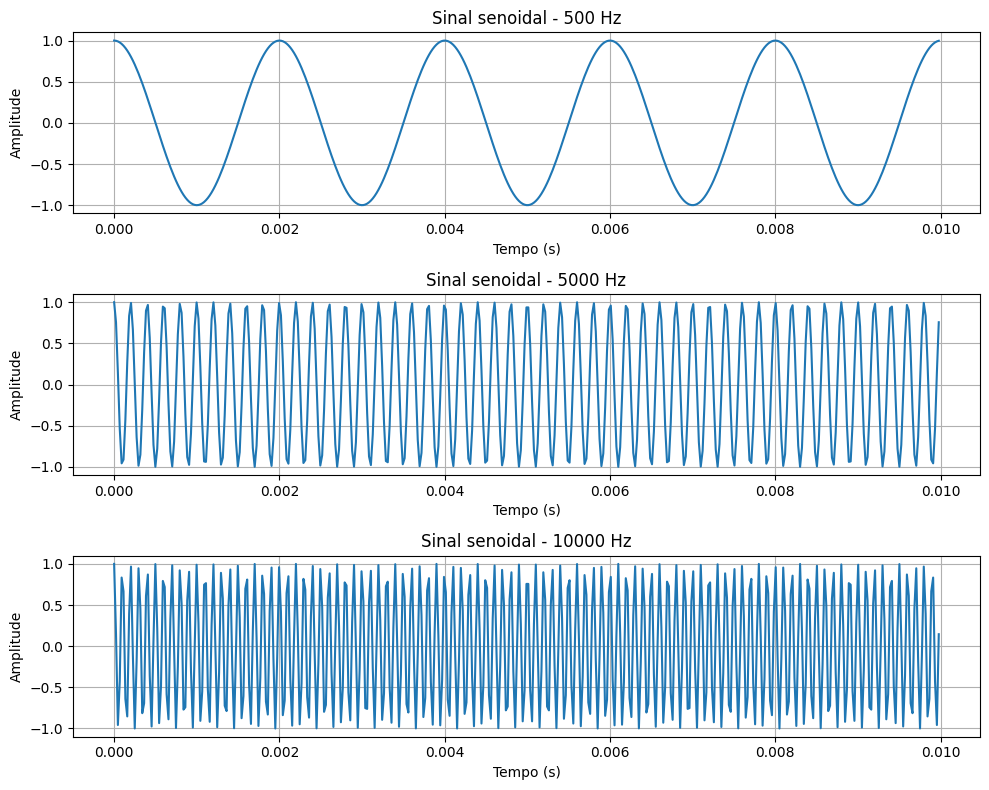

In [16]:
# Visualização dos primeiros 10 ms de cada sinal

tempo_zoom = 0.01
n_zoom = int(fs * tempo_zoom)

plt.figure(figsize=(10, 8))

for i, f in enumerate(frequencias, start=1):
    plt.subplot(3, 1, i)
    plt.plot(t[:n_zoom], sinais[f][:n_zoom])
    plt.title(f"Sinal senoidal - {f} Hz")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()

plt.tight_layout()
plt.savefig(
    PASTA_RESULTADOS / "q1_sinais_senoidais.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [17]:
!ls Aula-01/Resultados

q1_sinais_senoidais.png


In [15]:
# Reprodução dos sinais senoidais

for f in frequencias:
    print(f"Sinal de {f} Hz:")
    display(Audio(sinais[f], rate=fs))

Sinal de 500 Hz:


Sinal de 5000 Hz:


Sinal de 10000 Hz:


### Comentários dos resultados


Na reprodução dos sinais, percebe-se que o aumento da frequência produz tons progressivamente mais agudos.

O sinal de 500 Hz apresenta um tom relativamente grave quando comparado aos sinais de 5 kHz e 10 kHz.

Os três sinais apresentam a mesma amplitude e duração, diferindo apenas em sua frequência.

No intervalo de 10 ms utilizado para visualização, observa-se que o sinal de 500 Hz apresenta aproximadamente 5 ciclos, enquanto os sinais de 5 kHz e 10 kHz apresentam aproximadamente 50 e 100 ciclos, respectivamente.

Esse comportamento é consistente com a relação entre frequência e período, dada por $T = 1/f$.

Para a frequência de amostragem de 44,1 kHz, a frequência de Nyquist é de 22,05 kHz. Portanto, as três frequências analisadas estão abaixo desse limite e podem ser representadas sem ocorrência de aliasing devido à amostragem.

No gráfico do sinal de 10 kHz, a forma de onda apresenta visualmente menos pontos por período do que nos sinais de menor frequência.

Isso ocorre porque, com uma frequência de amostragem de 44,1 kHz, existem aproximadamente 4,41 amostras por período para o sinal de 10 kHz, enquanto o sinal de 500 Hz possui aproximadamente 88,2 amostras por período.